In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('/kaggle/input/datasets/amineipad/titanic-dataset/train.csv')
test = pd.read_csv('/kaggle/input/datasets/amineipad/titanic-dataset/test.csv')
print(train.shape)
print(train.head())

(891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN    

# Exploration des valeurs manquantes

In [3]:
print(train.isnull().sum())
print(f"\nTaux de survie global : {train['Survived'].mean() : .2%}")

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Taux de survie global :  38.38%


* **Age (177)** --> 20% de manquants, on peut imputer (médiane)
* **Cabin (687)** --> 77% de manquants, trop peu fiable --> on la supprime ou on crée une variable binaire HasCabin
* **Embarked (2)** --> seulement 2 manquants --> on impute avec le mode (la valeur la plus fréquente)

# Exploratory Data Analysis

## Distribution de la survie et des variables catégorielles

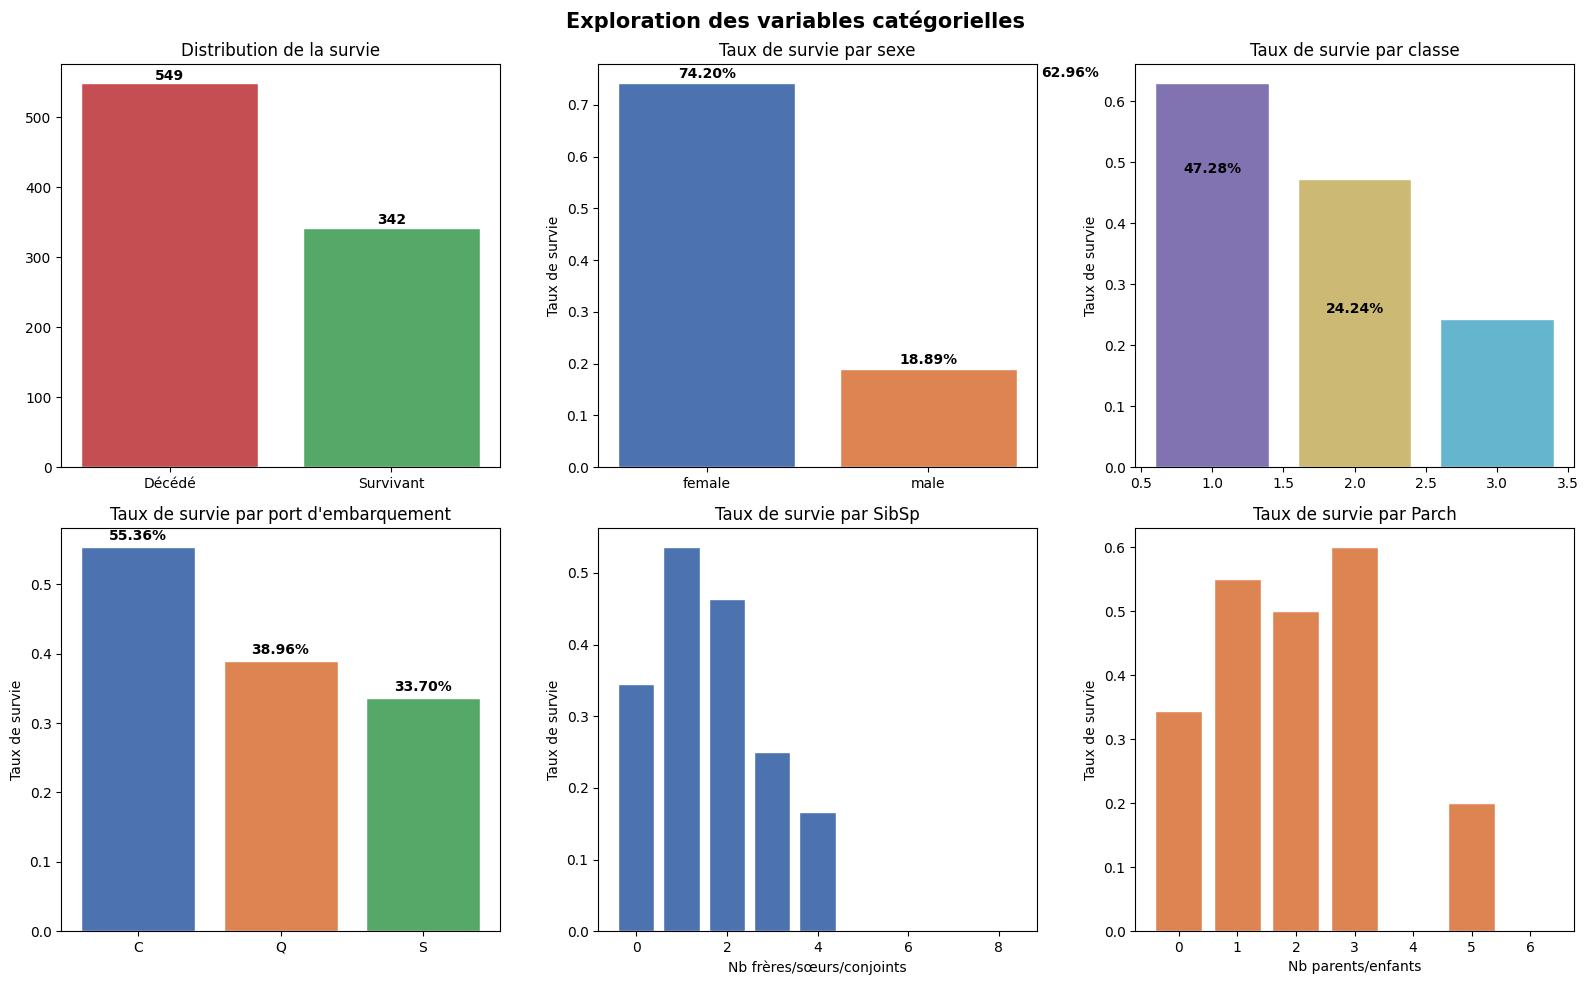

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Exploration des variables catégorielles', fontsize=15, fontweight='bold')

# Survie globale
axes[0,0].bar(['Décédé','Survivant'], train['Survived'].value_counts().sort_index(),
               color=['#C44E52','#55A868'], edgecolor='white')
axes[0,0].set_title('Distribution de la survie')
for i, v in enumerate(train['Survived'].value_counts().sort_index()):
    axes[0,0].text(i, v+5, str(v), ha='center', fontweight='bold')

# Survie par sexe
survival_sex = train.groupby('Sex')['Survived'].mean()
axes[0,1].bar(survival_sex.index, survival_sex.values,
               color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0,1].set_title('Taux de survie par sexe')
axes[0,1].set_ylabel('Taux de survie')
for i, v in enumerate(survival_sex.values):
    axes[0,1].text(i, v+0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Survie par classe
survival_pclass = train.groupby('Pclass')['Survived'].mean()
axes[0,2].bar(survival_pclass.index, survival_pclass.values,
               color=['#8172B2','#CCB974','#64B5CD'], edgecolor='white')
axes[0,2].set_title('Taux de survie par classe')
axes[0,2].set_ylabel('Taux de survie')
for i, v in enumerate(survival_pclass.values):
    axes[0,2].text(i, v+0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Survie par port d'embarquement
survival_emb = train.groupby('Embarked')['Survived'].mean()
axes[1,0].bar(survival_emb.index, survival_emb.values,
               color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[1,0].set_title("Taux de survie par port d'embarquement")
axes[1,0].set_ylabel('Taux de survie')
for i, v in enumerate(survival_emb.values):
    axes[1,0].text(i, v+0.01, f'{v:.2%}', ha='center', fontweight='bold')

# Distribution de SibSp
survival_sibsp = train.groupby('SibSp')['Survived'].mean()
axes[1,1].bar(survival_sibsp.index, survival_sibsp.values, color='#4C72B0', edgecolor='white')
axes[1,1].set_title('Taux de survie par SibSp')
axes[1,1].set_ylabel('Taux de survie')
axes[1,1].set_xlabel('Nb frères/sœurs/conjoints')

# Distribution de Parch
survival_parch = train.groupby('Parch')['Survived'].mean()
axes[1,2].bar(survival_parch.index, survival_parch.values, color='#DD8452', edgecolor='white')
axes[1,2].set_title('Taux de survie par Parch')
axes[1,2].set_ylabel('Taux de survie')
axes[1,2].set_xlabel('Nb parents/enfants')

plt.tight_layout()
plt.show()

## Variables continues (Age et Fare) 

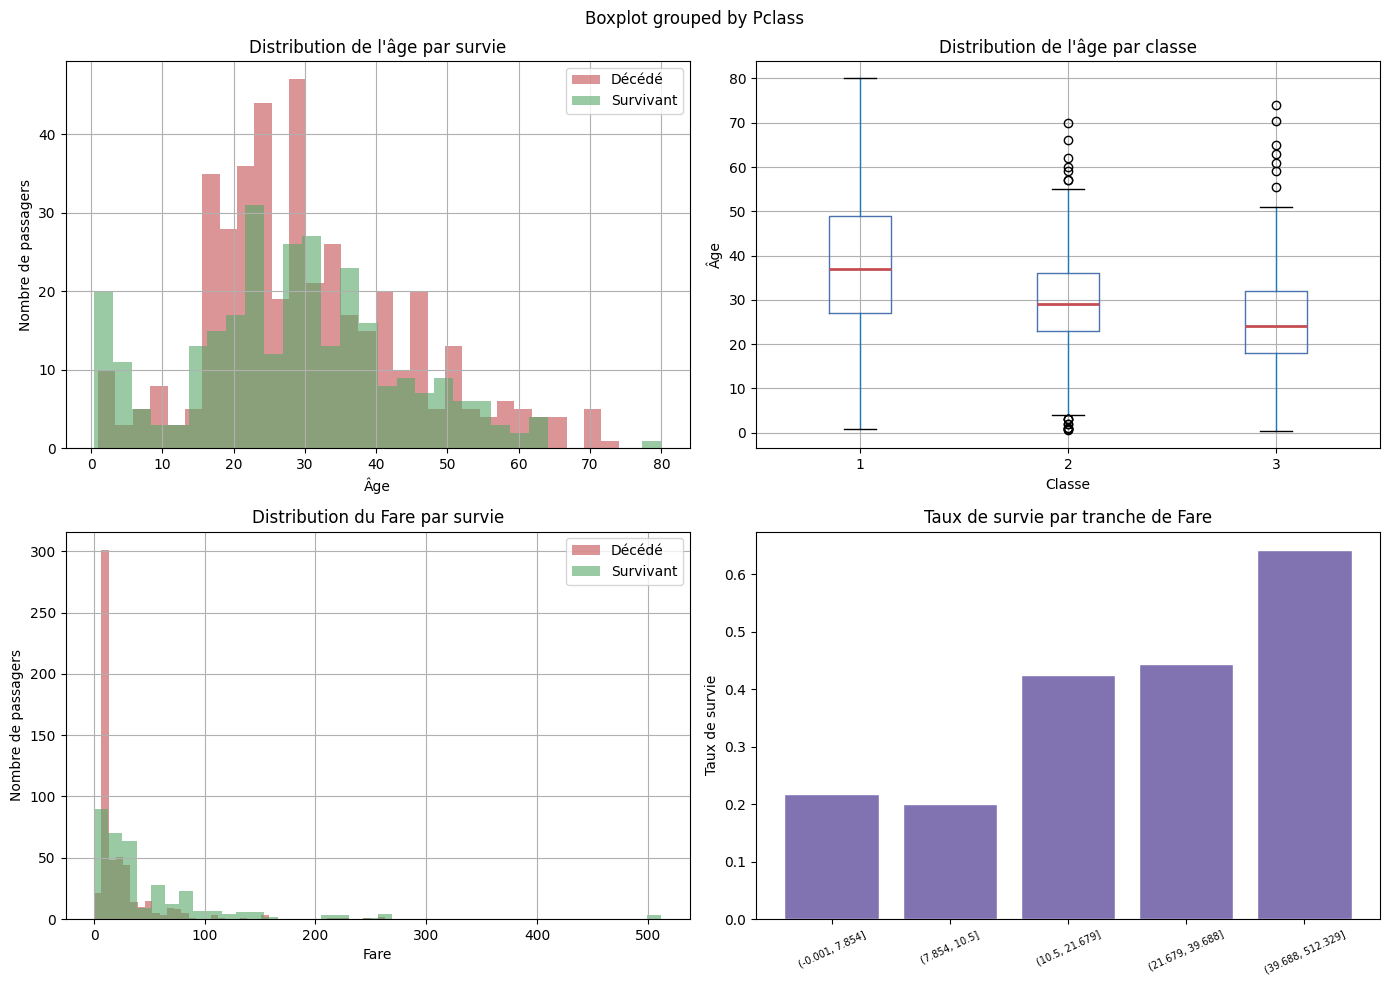

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploration des variables continues', fontsize=15, fontweight='bold')

# Distribution de l'âge par survie
train[train['Survived']==0]['Age'].dropna().hist(ax=axes[0,0], bins=30, 
     alpha=0.6, color='#C44E52', label='Décédé')
train[train['Survived']==1]['Age'].dropna().hist(ax=axes[0,0], bins=30,
     alpha=0.6, color='#55A868', label='Survivant')
axes[0,0].set_title('Distribution de l\'âge par survie')
axes[0,0].set_xlabel('Âge')
axes[0,0].set_ylabel('Nombre de passagers')
axes[0,0].legend()

# Boxplot Age par classe
train.boxplot(column='Age', by='Pclass', ax=axes[0,1],
              boxprops=dict(color='#4C72B0'),
              medianprops=dict(color='#C44E52', linewidth=2))
axes[0,1].set_title('Distribution de l\'âge par classe')
axes[0,1].set_xlabel('Classe')
axes[0,1].set_ylabel('Âge')
plt.sca(axes[0,1]); plt.title('Distribution de l\'âge par classe')

# Distribution du Fare par survie (log scale)
train[train['Survived']==0]['Fare'].hist(ax=axes[1,0], bins=40,
     alpha=0.6, color='#C44E52', label='Décédé')
train[train['Survived']==1]['Fare'].hist(ax=axes[1,0], bins=40,
     alpha=0.6, color='#55A868', label='Survivant')
axes[1,0].set_title('Distribution du Fare par survie')
axes[1,0].set_xlabel('Fare')
axes[1,0].set_ylabel('Nombre de passagers')
axes[1,0].legend()

# Taux de survie par tranche de Fare
train['FareBand'] = pd.qcut(train['Fare'], q=5)
survival_fare = train.groupby('FareBand', observed=True)['Survived'].mean()
axes[1,1].bar(range(len(survival_fare)), survival_fare.values,
               color='#8172B2', edgecolor='white')
axes[1,1].set_xticks(range(len(survival_fare)))
axes[1,1].set_xticklabels([str(i) for i in survival_fare.index], rotation=25, fontsize=7)
axes[1,1].set_title('Taux de survie par tranche de Fare')
axes[1,1].set_ylabel('Taux de survie')

plt.tight_layout()
plt.show()

# Nettoyage colonne temporaire
train.drop('FareBand', axis=1, inplace=True)

**Âge :**

* **Les enfants (0-10 ans)** ont un pic vert visible --> ils ont mieux survécu.
* **Les jeunes adultes (20-35 ans)** ont beaucoup de rouge --> forte mortalité.
* Les personnes agées survivent un peu moins bien aussi.

**Fare:**

* Tendance claire : plus le billet est cher, plus le taux de survie augmente.


### Heatmap corrélation

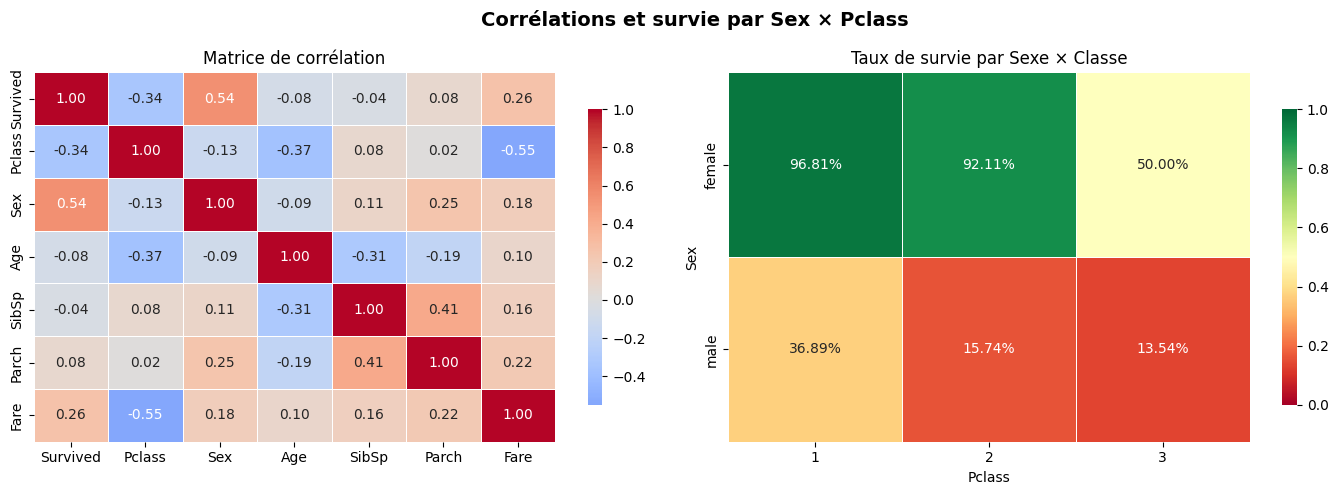

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Corrélations et survie par Sex × Pclass', fontsize=14, fontweight='bold')

# Heatmap corrélation
corr_cols = ['Survived','Pclass','Sex','Age','SibSp','Parch','Fare']
corr_data  = train[corr_cols].copy()
corr_data['Sex'] = corr_data['Sex'].map({'male':0,'female':1})
corr_matrix = corr_data.corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=axes[0], linewidths=0.5,
            cbar_kws={'shrink':0.8})
axes[0].set_title('Matrice de corrélation')

# Taux de survie Sex × Pclass
survival_pivot = train.pivot_table(values='Survived',
                                    index='Sex',
                                    columns='Pclass',
                                    aggfunc='mean')
sns.heatmap(survival_pivot, annot=True, fmt='.2%', cmap='RdYlGn',
            ax=axes[1], linewidths=0.5, vmin=0, vmax=1,
            cbar_kws={'shrink':0.8})
axes[1].set_title('Taux de survie par Sexe × Classe')

plt.tight_layout()
plt.show()

* Sex est la variable la plus corrélée avec Survived, suivi de Pclass et Fare.
* Le groupe (femme, 1ere classe) a le meilleur taux de survie, suivi du groupe (femme, 2ème classe) et (femme,3ème classe).
* Une femme en 3ème classe survit mieux qu'un homme en 1ère classe. Ça veut dire que Sex domine Pclass

# Feature engineering

In [7]:
from sklearn.preprocessing import LabelEncoder

def preprocess(df):
    data = df.copy()
    
    # Extraction du titre
    data['Title'] = data['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    
    # Regroupement — Dona ajouté dans Rare
    data['Title'] = data['Title'].replace(['Lady','Countess','Capt','Col','Don','Dona',
                                           'Dr','Major','Rev','Sir','Jonkheer'], 'Rare')
    data['Title'] = data['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
    
    # Mapping manuel — plus robuste que LabelEncoder
    title_map = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
    data['Title'] = data['Title'].map(title_map).fillna(4)  # inconnu → Rare
    
    # Taille de la famille
    data['FamilySize'] = data['SibSp'] + data['Parch'] + 1
    data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
    
    # Cabin
    data['HasCabin'] = data['Cabin'].notna().astype(int)
    
    # Encodage manuel — même logique
    data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
    data['Embarked'] = data['Embarked'].fillna('S').map({'S': 0, 'C': 1, 'Q': 2})
    
    features = ['Pclass','Sex','Age','Fare','Embarked',
                'Title','FamilySize','IsAlone','HasCabin']
    return data[features]
    
X = preprocess(train)
y = train['Survived']

print(X.shape)
X.head()

(891, 9)


,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,IsAlone,HasCabin
0,3,0,22.0,7.2500,0,0,2,0,0
1,1,1,38.0,71.2833,1,2,2,0,1
2,3,1,26.0,7.9250,0,1,1,1,0
3,1,1,35.0,53.1000,0,2,2,0,1
4,3,0,35.0,8.0500,0,0,1,1,0


# Split train/validation + définition des modèles

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # stratify=y --> garantit le taux de survie est conservé dans les 2 splits

print(f"Train : {X_train.shape}, Validation : {X_val.shape}")
print(f"Taux de survie train : {y_train.mean() : .2%}")
print(f"Taux de survie Validation : {y_val.mean() : .2%}")

Train : (712, 9), Validation : (179, 9)
Taux de survie train :  38.34%
Taux de survie Validation :  38.55%


# Définition des pipelines

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

def make_pipe(clf, scale=True):
    steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale :
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', clf))
    return Pipeline(steps)

models = {
    'Logistic Regression' : make_pipe(LogisticRegression(max_iter=1000, random_state=42)),
    'Randomm Forest' : make_pipe(RandomForestClassifier(n_estimators=200, random_state=42)),
    'XGBoost' : make_pipe(XGBClassifier(n_estimators=200, eval_metric='logloss', random_state=42), scale=False),
    'SVM (RBF)':           make_pipe(SVC(probability=True, random_state=42)),
    'KNN':                 make_pipe(KNeighborsClassifier(n_neighbors=7)),
}

# Cross-validation sur tous les modèles

In [10]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score,  roc_curve, confusion_matrix, classification_report


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, pipe in models.items() :
    cv_acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc')
    results[name] = {
        'cv_acc_mean' : cv_acc.mean(),
        'cv_acc_std' : cv_acc.std(),
        'cv_auc_mean' : cv_auc.mean(),
        'cv_auc_std' : cv_auc.std()
    }
    print(f"{name:<<22} Acc={cv_acc.mean():.3f}±{cv_acc.std():.3f}  AUC = {cv_auc.mean():.3f}±{cv_auc.std():.3f}")
    

Logistic Regression<<< Acc=0.815±0.028  AUC = 0.869±0.018
Randomm Forest<<<<<<<< Acc=0.817±0.018  AUC = 0.879±0.014
XGBoost<<<<<<<<<<<<<<< Acc=0.808±0.021  AUC = 0.881±0.011
SVM (RBF)<<<<<<<<<<<<< Acc=0.836±0.022  AUC = 0.870±0.027
KNN<<<<<<<<<<<<<<<<<<< Acc=0.815±0.012  AUC = 0.865±0.021


**Ce qu'on observe :**

* **XGBoost** a le meilleur AUC (0.881) et sa variance est la plus faible (±0.11)--> il est stble et précis.
* **SVM** a la meilleur Accuracy (0.836) mais avec plus de variance (±0.22).
* **Random Forest** est très équilibré et a la plus faible variance (±0.18/±0.14) --> il généralise bien.
* **KNN et Logistic Regression** sont dans la moyenne, sans se démarquer.

# Evaluation finale sur le set de validation

In [11]:
for name, pipe in models.items() :
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    y_proba = pipe.predict_proba(X_val)[:, 1]
    results[name]['test_acc'] = accuracy_score(y_val, y_pred)
    results[name]['test_auc'] = roc_auc_score(y_val, y_proba)
    results[name]['y_pred'] = y_pred
    results[name]['y_proba'] = y_proba
    print(f"{name:<22} Val Acc={results[name]['test_acc']:.3f}  Val AUC={results[name]['test_auc']:.3f}")

Logistic Regression    Val Acc=0.793  Val AUC=0.853
Randomm Forest         Val Acc=0.804  Val AUC=0.836
XGBoost                Val Acc=0.816  Val AUC=0.837
SVM (RBF)              Val Acc=0.821  Val AUC=0.839
KNN                    Val Acc=0.782  Val AUC=0.853


**Ce qu'on apprend :**

* **RF et XGBoost ont overfit** - leur AUC chute de ~0.04 entre CV et validation. Ce sont des modèles puissant mais gourmands, qui mémorisent le bruit sans tuning.
* **Logistic Regression et SVM sont les plus stables** - faible écart CV/Val, ils généralisent mieux sur ce dataset.

# Visualisation des courbes ROC

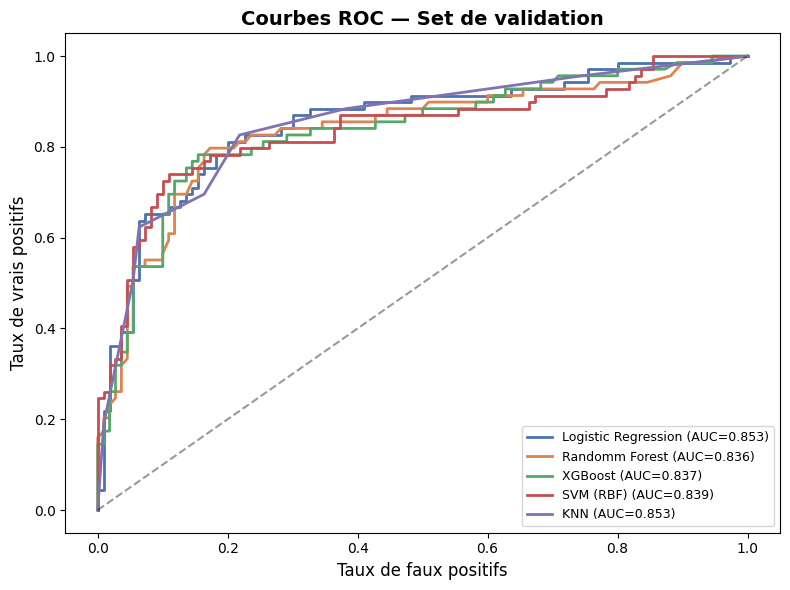

In [12]:
plt.figure(figsize=(8, 6))
colors = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, r['y_proba'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{name} (AUC={r['test_auc']:.3f})")

plt.plot([0,1],[0,1], 'k--', alpha=0.4)
plt.xlabel('Taux de faux positifs', fontsize=12)
plt.ylabel('Taux de vrais positifs', fontsize=12)
plt.title('Courbes ROC — Set de validation', fontsize=14, fontweight='bold')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

# Matrice de confusion

Sur la base de la stabilité CV/Val, on choisit **SVM** (meilleur compromis Accuracy + AUC + stabilité).

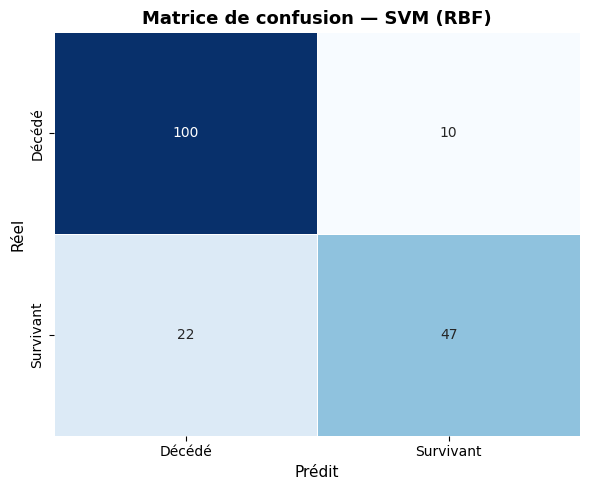

              precision    recall  f1-score   support

      Décédé       0.82      0.91      0.86       110
   Survivant       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



In [13]:
best_name = 'SVM (RBF)'
best_pipe = models[best_name]

cm = confusion_matrix(y_val, results[best_name]['y_pred'])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Décédé', 'Survivant'],
            yticklabels=['Décédé', 'Survivant'], 
            linewidths=0.5, cbar=False)
plt.title(f'Matrice de confusion — {best_name}', fontsize=13, fontweight='bold')
plt.ylabel('Réel', fontsize=11)
plt.xlabel('Prédit', fontsize=11)
plt.tight_layout()
plt.show()

print(classification_report(y_val, results[best_name]['y_pred'], 
                           target_names=['Décédé', 'Survivant']))

**La matrice en clair:**

* 100 décédés bien classés, 10 mal classés --> le modèle est très bon sur les décédés.
* 47 survivants bien classés, 22 mal classés --> plus difficile sur les survivants.

**Ce que dit le classification report**

* **Précision 0.82** sur Survivant --> quand il dit "survivant", il a raison 82% du temps.
* **Recall 0.68** sur survivant --> il rate 32% des vrais survivants.
* **F1-score global 0.82** --> bon équilibre général.

# Préparation de la soumission Kaggle

In [14]:
# Prétraitement du jeu de test
X_test = preprocess(test)

# Entraînement sur TOUT le train (plus de split)
best_pipe.fit(X, y)

# Prédictions
predictions = best_pipe.predict(X_test)

# Fichier de soumission
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Survived':    predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))
print(f"\nShape : {submission.shape}")
print(f"Taux de survie prédit : {submission['Survived'].mean():.2%}")

   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Shape : (418, 2)
Taux de survie prédit : 36.60%
